In [1]:
import sys
print(sys.executable)

/Users/dipasmitadebroy/Documents/Artificial_Intelligence/ml_projects/movie-recommender/venv/bin/python


In [2]:
#Load all the models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, warnings

warnings.filterwarnings("ignore")
%matplotlib inline

MODEL_DIR   = "../models/"
FIGURES_DIR = "../reports/figures/"

baseline = joblib.load(MODEL_DIR + "baseline_cf.joblib")
svd_art  = joblib.load(MODEL_DIR + "svd.joblib")
nmf_art  = joblib.load(MODEL_DIR + "nmf.joblib")
ncf_art  = joblib.load(MODEL_DIR + "ncf_meta.joblib")
als_art  = joblib.load(MODEL_DIR + "als.joblib")

print("✅ All model artifacts loaded")

✅ All model artifacts loaded


In [3]:
#Build a leaderboard

results = [
    baseline["results"],
    svd_art["results"],
    nmf_art["results"],
    ncf_art["results"],
    als_art["results"],
]

leaderboard = pd.DataFrame(results).set_index("model").sort_values("RMSE")

print("\n🏆 Model Leaderboard")
print("=" * 35)
print(leaderboard.to_string())
print("=" * 35)


🏆 Model Leaderboard
            RMSE       MAE
model                     
SVD     0.792666  0.594850
NCF     0.824505  0.620201
NMF     0.887279  0.668919
UserCF  0.962862  0.744336
ALS     1.395611  1.035706


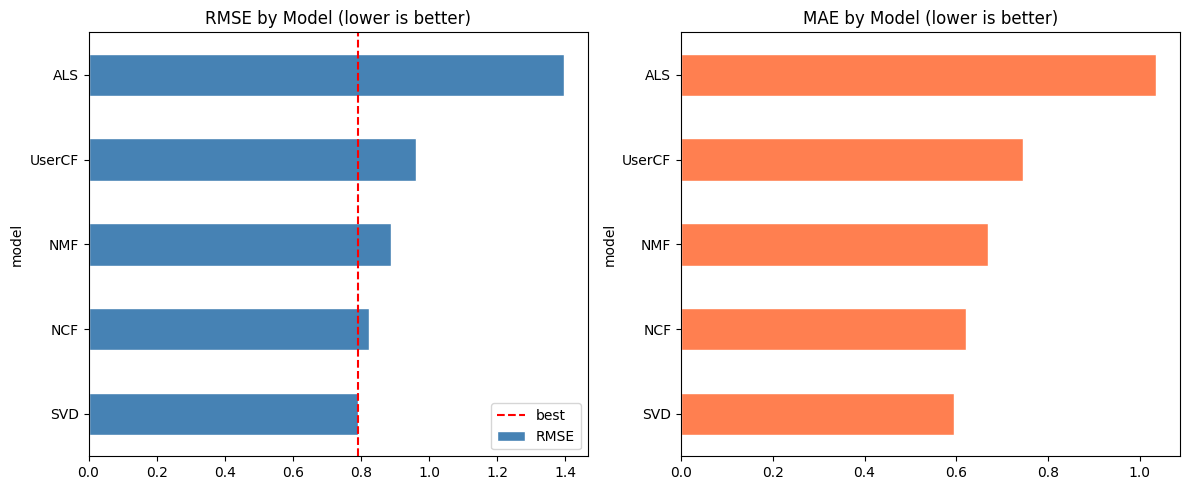

In [4]:
#Visualize

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

leaderboard["RMSE"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("RMSE by Model (lower is better)")
axes[0].axvline(leaderboard["RMSE"].min(), color="red", ls="--", label="best")
axes[0].legend()

leaderboard["MAE"].sort_values().plot(kind="barh", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("MAE by Model (lower is better)")

plt.tight_layout()
plt.savefig(FIGURES_DIR + "model_comparison.png", dpi=150)
plt.show()

In [5]:
#save the leaderboard

leaderboard.to_csv("../reports/leaderboard.csv")
print("✅ Leaderboard saved — move to 08_ensembling.ipynb")

✅ Leaderboard saved — move to 08_ensembling.ipynb
